In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from datatools.fixture import setup_dummy_data
# test_tool
# source = setup_dummy_data(5)

# put data into this source folder
source = "./tool-tracking-data/"

In [2]:
from datatools import MeasurementDataReader, Measurement, MeasurementSeries, Action
mdr = MeasurementDataReader(source=source)

In [3]:
q = mdr.query(query_type=Measurement)

In [4]:
from datatools import Tool, Config, MeasurementSeries, Measurement, DataTypes, Action
from datatools import ACC, GYR, MAG, MIC, POS, VEL

mytool = "electric_screwdriver"
# mytool = "pneumatic_screwdriver"
# mytool = "pneumatic_rivet_gun"
#mytool = "test_tool"

data_dict = q.filter_by(Tool == mytool, DataTypes == ACC).get()

[INFO] Preparing data from:
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716


[INFO] Read annotation: 100%|██████████| 16/16 [00:00<00:00, 306.48it/s, file=data-03.annotation]

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-02-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-04-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-03-102.291.csv) and from the timestamps differ by 0.001Hz

[INFO] Finished with 4 measurement(s).


In [ ]:
data_dict.keys()  # we have loaded five measurements 

In [65]:
data_bunch = data_dict["01"] # data bunch for measurement with measurement id "01"
type(data_bunch) 

datatools.data.DataBunch

In [66]:
data_bunch.data_keys()

['acc']

In [67]:
data_bunch.acc.features

['acceleration x-axis [m/s^2]',
 'acceleration y-axis [m/s^2]',
 'acceleration z-axis [m/s^2]']

In [68]:
len(data_bunch.acc)  # number of samples in this measurement

41775

In [69]:
data_bunch.classes

{3: 'untightening',
 8: 'undefined',
 5: 'motor_activity_ccw',
 2: 'tightening',
 6: 'manual_motor_rotation',
 14: 'tightening_double',
 7: 'shaking',
 4: 'motor_activity_cw'}

In [70]:
# matrix with raw sensor data with time column
Xt = data_bunch.acc.ts # numpy array

# matrix with raw sensor data (without time column)
X = data_bunch.acc.X  # numpy array

# target vector
y = data_bunch.acc.y  # numpy array

In [71]:
print("shape of Xt: ", Xt.shape)
print("shape of X: ", X.shape)
print("shape of y: ", y.shape)

shape of Xt:  (41775, 4)
shape of X:  (41775, 3)
shape of y:  (41775,)


In [72]:
type(y)

numpy.ndarray

In [73]:
np.unique(y)  # unique class labels in y

array([-1.,  2.,  3.,  4.,  5.,  6.,  7.,  8., 14.])

In [74]:
import pandas as pd
df = pd.DataFrame({"class_label": y})

In [75]:
df.groupby('class_label').size()  # counts per class

class_label
-1.0         3
 2.0      4322
 3.0      1924
 4.0      1801
 5.0       701
 6.0       279
 7.0       629
 8.0     32048
 14.0       68
dtype: int64

In [76]:
from seglearn.base import TS_Data
from seglearn.pipe import Pype
from fhgutils import Segment, contextual_recarray_dtype, filter_ts_data
from datatools import to_ts_data

In [77]:
window_length=0.4 # unit in s
overlap = 0.25 # unit in percent

# clean and window data
data_dict = mdr.query().filter_by(Tool == mytool).get()
Xt, Xc, y = to_ts_data(data_dict, contextual_recarray_dtype)

X = TS_Data(Xt, Xc)
pipe = Pype([
    ('segment', Segment(window_length=window_length, overlap=overlap, enforce_size=True, n=len(np.unique(Xc.desc))))
])

X_trans, y_trans = pipe.fit_transform(X, y)

[INFO] Preparing data from:
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716


[INFO] Read data:   0%|          | 0/16 [00:00<?, ?it/s]

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-04-154.967.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-02-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-02-154.679.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-02-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-01-155.08

[INFO] Read data:  81%|████████▏ | 13/16 [00:00<00:00, 24.83it/s, file=MIC-04-8000.csv]

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-04-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-03-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-03-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-03-154.871.csv) and from the timestamps differ by 0.002Hz



[INFO] Read annotation: 100%|██████████| 16/16 [00:01<00:00, 14.74it/s, file=data-03.annotation]


[INFO] Finished with 4 measurement(s).
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
Segment: 100%|██████████| 19380/19380 [00:00<00:00, 189547.20it/s]


In [78]:
print("[INFO] extract segmented ACC data")
Xt_acc, Xc_acc, y_acc = filter_ts_data(X_trans, y_trans, filt={'desc': ['acc']})

print("[INFO] extract segmented GYR data")
Xt_gyr, Xc_gyr, y_gyr = filter_ts_data(X_trans, y_trans, filt={'desc': ['gyr']})

[INFO] extract segmented ACC data
[INFO] extract segmented GYR data


In [79]:
print("[INFO] shape of ACC data is", Xt_acc.shape)
print("[INFO] shape of GYR data is", Xt_gyr.shape)
print(f"[INFO] {Xt_acc.shape[0]} windows with {Xt_acc[0].shape[1]} sample each (time stamps and 3 axis accelerometer)")

[INFO] shape of ACC data is (4845,)
[INFO] shape of GYR data is (4845,)
[INFO] 4845 windows with 4 sample each (time stamps and 3 axis accelerometer)


In [80]:
Xt_acc[0].shape

(41, 4)

In [81]:
from fhgutils import filter_labels, one_label_per_window, summarize_labels

In [82]:
values, counts = np.unique(y_acc, return_counts=True)
for val, count in zip(values, counts):
    print(f"[INFO] label {val} with {count} samples")

[INFO] label -1.0 with 8 samples
[INFO] label 2.0 with 22655 samples
[INFO] label 3.0 with 9704 samples
[INFO] label 4.0 with 8410 samples
[INFO] label 5.0 with 3744 samples
[INFO] label 6.0 with 2056 samples
[INFO] label 7.0 with 2443 samples
[INFO] label 8.0 with 149196 samples
[INFO] label 14.0 with 429 samples


In [83]:
Xt_acc_f, Xc_acc_f, y_acc_f = filter_labels(labels=[-1], Xt=Xt_acc, Xc=Xc_acc, y=y_acc)

[INFO] original Xt: 4845 (41, 4)
[INFO] filtered Xt: 4843 (41, 4)


In [84]:
print("pre", y_acc_f[5])
y_acc_f = one_label_per_window(y=y_acc_f)
print("post", y_acc_f[5])

pre [8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8.
 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8.]
flattened 8 labels: [ 2  3  4  5  6  7  8 14]
post 8


In [85]:
y_acc_f[3000]

4

In [86]:
Xc_acc_f[0]

np.record((None, 102.291, 4, 'acc', 0.0), dtype=[('cls', 'O'), ('sr', '<f8'), ('id', '<i8'), ('desc', 'O'), ('height', '<f8')])

In [87]:
import torch
from torch.utils.data import Dataset
import numpy as np
from datatools import MeasurementDataReader, Measurement, Tool
from datatools import to_ts_data
from fhgutils import Segment, contextual_recarray_dtype, filter_ts_data
from fhgutils import filter_labels, one_label_per_window
from seglearn.base import TS_Data
from seglearn.pipe import Pype

In [88]:
class ToolTrackingDataset(Dataset):
    def __init__(self, source_path, tool_name="electric_screwdriver", sensor_type='acc', window_length=0.4, overlap=0.25, without_time=True):
        self.source_path = source_path
        
        mdr = MeasurementDataReader(source=source_path)
        
        print(f"[INFO] Querying data for tool: {tool_name}...")
        self.data_dict = mdr.query().filter_by(Tool == tool_name).get()

        print("[INFO] Converting to TS Data...")
        Xt, Xc, y = to_ts_data(self.data_dict, contextual_recarray_dtype)
        
        print(f"[INFO] Segmenting data (Window: {window_length}s, Overlap: {overlap})...")
        X_obj = TS_Data(Xt, Xc)
                
        pipe = Pype([
            ('segment', Segment(window_length=window_length, 
                                overlap=overlap, 
                                enforce_size=True, 
                                n=len(np.unique(Xc.desc))))
        ])
        
        X_trans, y_trans = pipe.fit_transform(X_obj, y)
        
        print(f"[INFO] Extracting specific sensor: {sensor_type}...")
        Xt_sens, Xc_sens, y_sens = filter_ts_data(X_trans, y_trans, filt={'desc': [sensor_type]})
        # Xt_stacked = np.stack(Xt_sens)
        
        
        Xt_sens = np.stack(Xt_sens)
        self.times = Xt_sens[:, :, 0]
        if without_time:
            Xt_sens = Xt_sens[:, :, 1:]

        
        print("[INFO] Cleaning labels...")
        Xt_sens_f, Xc_sens_f, y_sens_f = filter_labels(labels=[-1], Xt=Xt_sens, Xc=Xc_sens, y=y_sens)
        self.y_sens_f = y_sens_f
        y_clean = one_label_per_window(y=y_sens_f)
        
        self.X = torch.tensor(Xt_sens_f, dtype=torch.float32)
        self.y = torch.tensor(y_clean, dtype=torch.long)
        
        print(f"[INFO] Dataset ready. Shape: {self.X.shape}")

    def __len__(self):
        return len(self.y)
    
    def get_senf(self):
        return self.y_sens_f

    def get_times(self):
        return self.times

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [89]:
source_folder = "./tool-tracking-data/"

In [90]:
dataset = ToolTrackingDataset(
    source_path=source_folder,
    tool_name="electric_screwdriver",
    sensor_type='acc',
    window_length=0.4,
    overlap=0.1,
    without_time=True
)

[INFO] Querying data for tool: electric_screwdriver...
[INFO] Preparing data from:
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716
  tool-tracking-data/electric_screwdriver/pythagoras-10-20200716


[INFO] Read data:   0%|          | 0/16 [00:00<?, ?it/s]

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-04-154.967.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-02-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-02-154.679.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-02-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-01-155.08

[INFO] Read data:  81%|████████▏ | 13/16 [00:00<00:00, 25.23it/s, file=MIC-04-8000.csv]

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-01-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-04-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/GYR-03-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/ACC-03-102.291.csv) and from the timestamps differ by 0.001Hz

[WARN] The mean sampling rate from the filename (tool-tracking-data/electric_screwdriver/pythagoras-10-20200716/MAG-03-154.871.csv) and from the timestamps differ by 0.002Hz



[INFO] Read annotation: 100%|██████████| 16/16 [00:01<00:00, 15.38it/s, file=data-03.annotation]


[INFO] Finished with 4 measurement(s).
[INFO] Converting to TS Data...
[INFO] Segmenting data (Window: 0.4s, Overlap: 0.1)...
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
[INFO] segment ['acc' 'gyr' 'mag' 'mic'] together
Segment: 100%|██████████| 16148/16148 [00:00<00:00, 198400.08it/s]
[INFO] Extracting specific sensor: acc...
[INFO] Cleaning labels...
[INFO] original Xt: 4037 (41, 3)
[INFO] filtered Xt: 4035 (41, 3)
flattened 8 labels: [ 2  3  4  5  6  7  8 14]
[INFO] Dataset ready. Shape: torch.Size([4035, 41, 3])


In [91]:
print("Feature Shape", dataset[1000][0].shape)
print("Target", dataset[0][1])

Feature Shape torch.Size([41, 3])
Target tensor(8)


In [92]:
len(dataset)

4035

In [93]:
d = {}

In [94]:
y_senf = dataset.get_senf()

In [95]:
y_clean = one_label_per_window(y=dataset.get_senf())

flattened 8 labels: [ 2  3  4  5  6  7  8 14]


In [96]:
for i in y_clean:
    nums = d.setdefault(i, 0)
    nums += 1
    d[i] = nums


In [97]:
d

{8: 3024, 2: 463, 3: 203, 6: 40, 14: 11, 4: 166, 5: 78, 7: 50}

In [98]:
import matplotlib.pyplot as plt

In [99]:
def plot_segments(Xt, times, class_names, indices=None, ncols=1, figsize_per_plot=(6,3)):
    plt.figure(figsize=(24,4))
    plt.title(f"Single window")
    t = times
    x_win = Xt
    plt.plot(t, x_win)
    plt.xlabel('Time [a.u.]')
    plt.ylabel('sensor values acc')
    plt.show()

In [100]:
y_times = dataset.get_times()

In [101]:
y_times[70]

array([1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09, 1.59422879e+09, 1.59422879e+09, 1.59422879e+09,
       1.59422879e+09])

In [102]:
Xt = dataset[74][0]
times = y_times[74]  # dummy time vector
class_names = y_senf[74]

In [103]:
dataset[74][0]

tensor([[ 4.0400, -4.1749,  9.2758],
        [ 3.5334, -2.9974,  9.3384],
        [ 2.9442, -1.8168,  9.3288],
        [ 2.4257, -0.7752,  9.3113],
        [ 2.1233,  0.1514,  9.2201],
        [ 1.9329,  0.9623,  9.1202],
        [ 1.7653,  1.5472,  9.0952],
        [ 1.6698,  1.7046,  9.0367],
        [ 1.4534,  1.6256,  9.0514],
        [ 1.2777,  1.5835,  9.1192],
        [ 1.5782,  1.6515,  9.1641],
        [ 1.6373,  1.4382,  9.2890],
        [ 1.5832,  1.1020,  9.0988],
        [ 1.5857,  0.8929,  8.8456],
        [ 1.8673,  0.5871,  8.7245],
        [ 1.9320,  0.3588,  8.6477],
        [ 1.7943,  0.2877,  8.7465],
        [ 1.0906,  0.9091,  9.5129],
        [ 0.6961, -0.0871,  9.1463],
        [ 1.0145, -0.6714,  9.6862],
        [ 1.3949,  0.0775,  9.0599],
        [ 1.6273,  0.2593,  9.0868],
        [ 1.5963,  0.3969,  9.2076],
        [ 1.6282,  0.3786,  9.1119],
        [ 1.5813,  0.3358,  9.1485],
        [ 1.7482,  0.4439,  9.2983],
        [ 1.7534,  0.5902,  9.3793],
 

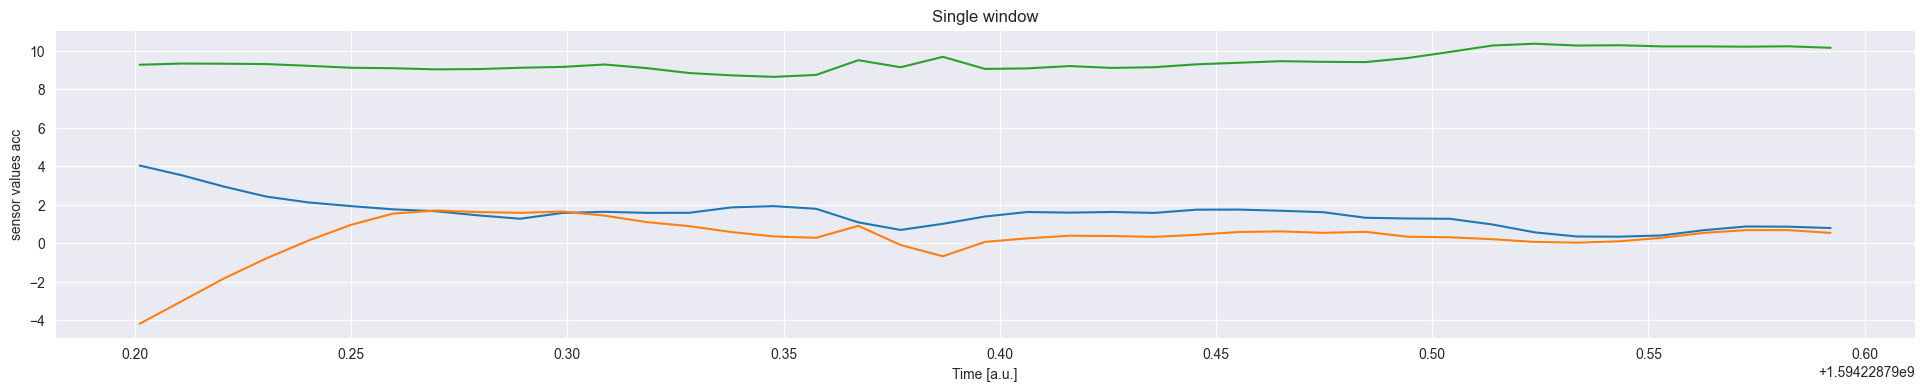

In [104]:
plot_segments(Xt, times, class_names, indices=None, ncols=1, figsize_per_plot=(6,3))